In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset
from pathlib import Path
from tqdm import tqdm
from config import TrainConfig
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.nn.functional as F


class RWF2000Skeletons(Dataset):
    def __init__(
        self,
        root: str | Path,
        split: str = "train",
        key: str = "skeletons",
        channels: tuple[int, ...] | None = None,  # None → use all channels
    ):
        self.root = Path(root)
        self.split = split
        self.key = key
        self.channels = channels

        split_dir = self.root / split
        if not split_dir.exists():
            raise FileNotFoundError(f"Missing split directory: {split_dir}")

        self.samples: list[tuple[Path, int, int]] = []
        for label_name, label in [("Fight", 1), ("NonFight", 0)]:
            label_dir = split_dir / label_name
            if not label_dir.exists():
                continue
            for npz_path in sorted(label_dir.glob("*.npz")):
                with np.load(npz_path) as data:
                    n = data[self.key].shape[0]
                for idx in range(n):
                    self.samples.append((npz_path, label, idx))
        if not self.samples:
            raise RuntimeError(f"No skeleton files found under {split_dir}")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int):
        npz_path, label, window_idx = self.samples[index]
        with np.load(npz_path) as data:
            window = data[self.key][window_idx]  # (T, V, C_full)
            label_arr = data.get("labels")
            if label_arr is not None:
                label = int(label_arr[window_idx])

        target_len = window.shape[0]
        if self.split == "train":
            # Temporal drop/crop: keep ~80–90% of frames, then pad/truncate back to target_len
            if window.shape[0] > 8 and np.random.rand() < 0.5:
                keep = np.sort(
                    np.random.choice(window.shape[0], int(window.shape[0] * np.random.uniform(0.8, 0.9)), replace=False)
                )
                window = window[keep]
            # Coord jitter: small noise on x/y
            if np.random.rand() < 0.7:
                noise = np.random.normal(0, 0.01, size=window[..., :2].shape)
                window[..., :2] += noise
            # Restore fixed temporal length for batching
            curr_len = window.shape[0]
            if curr_len < target_len:
                pad_shape = (target_len - curr_len, window.shape[1], window.shape[2])
                pad = np.zeros(pad_shape, dtype=window.dtype)
                window = np.concatenate([window, pad], axis=0)
            elif curr_len > target_len:
                window = window[:target_len]

        window_sel = window if self.channels is None else window[..., list(self.channels)]
        window_sel = np.transpose(window_sel, (2, 0, 1)).astype(np.float32)  # (C, T, V)
        return torch.from_numpy(window_sel), torch.tensor(label, dtype=torch.long)


In [ ]:
def build_coco_adjacency(num_joints: int = 17):
    # Edge list (COCO keypoint order: 0-nose,1-eyeL,2-eyeR,3-earL,4-earR,5-shoulderL,6-shoulderR,
    # 7-elbowL,8-elbowR,9-wristL,10-wristR,11-hipL,12-hipR,13-kneeL,14-kneeR,15-ankleL,16-ankleR)
    edges = [
        (0, 1), (0, 2), (1, 3), (2, 4),
        (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
        (11, 12), (5, 11), (6, 12),
        (11, 13), (13, 15), (12, 14), (14, 16)
    ]
    A = torch.eye(num_joints)
    for i, j in edges:
        A[i, j] = 1
        A[j, i] = 1
    # Normalize
    D = torch.diag(1.0 / torch.clamp(A.sum(dim=1), min=1.0))
    return D @ A


class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, A, stride=1, residual=True, dropout=0.0):
        super().__init__()
        self.A = nn.Parameter(A, requires_grad=False)  # static adjacency, can make learnable
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=(9, 1), stride=(stride, 1), padding=(4, 0))
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.drop = nn.Dropout(dropout)
        if not residual:
            self.residual = lambda x: 0
        elif in_channels == out_channels and stride == 1:
            self.residual = lambda x: x
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        # x: (B, C, T, V)
        res = self.residual(x)
        x = torch.einsum("nctv,vw->nctw", x, self.A)  # spatial graph conv (message passing)
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.drop(x)
        return x + res


class STGCN(nn.Module):
    def __init__(self, num_classes=2, in_channels=2, graph_nodes=17, base_channels=64, dropout=0.5):
        super().__init__()
        A = build_coco_adjacency(graph_nodes)
        self.register_buffer("A", A)

        channels = [base_channels, base_channels, base_channels, 2*base_channels, 2*base_channels, 4*base_channels]
        strides = [1, 1, 1, 2, 1, 2]  # temporal downsampling
        layers = []
        c_in = in_channels
        for c_out, s in zip(channels, strides):
            layers.append(GraphConv(c_in, c_out, self.A, stride=s, residual=True, dropout=dropout))
            c_in = c_out
        self.stgcn = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(channels[-1], num_classes)

    def forward(self, x):
        # x: (B, C, T, V)
        x = self.stgcn(x)
        x = self.pool(x)              # (B, C_out, 1, 1)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [3]:
cfg = TrainConfig()
cfg.batch_size = 64
cfg.max_epochs = 10
train_ds = RWF2000Skeletons("precomputed_skeletons", split="train")
val_ds = RWF2000Skeletons("precomputed_skeletons", split="val")

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.workers)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.workers)

X_probe, _ = next(iter(train_loader))
Fdim = X_probe.shape[-1]

model_device = 'mps'

In [4]:
base_channels = 64

model = STGCN(
    num_classes=cfg.num_classes,
    in_channels=7,
    graph_nodes=17,
    base_channels=base_channels,
    dropout=cfg.dropout,
).to(model_device)


In [5]:
import os
save_path = "checkpoints/best_model_2.pth"
criterion = nn.CrossEntropyLoss()
optim = torch.optim.AdamW(model.parameters(), lr=cfg.lr)

ckpt_dir = os.path.dirname(save_path)
if ckpt_dir:
    os.makedirs(ckpt_dir, exist_ok=True)

In [6]:
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.utils import clip_grad_norm_

cfg.lr = 3e-4
cfg.weight_decay = 1e-4
cfg.dropout = 0.2
cfg.joint_dropout = 0.1
max_epochs = cfg.max_epochs

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optim = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = ReduceLROnPlateau(optim, mode="max", factor=0.5, patience=1, threshold=1e-3)
patience, bad_epochs = 3, 0
best_acc = -1.0
best_cm = None  # (labels, preds)

train_losses, train_accs, train_f1s, train_aucs = [], [], [], []
val_losses, val_accs, val_f1s, val_aucs = [], [], [], []

for epoch in range(max_epochs):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    all_preds, all_labels, all_probs = [], [], []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}")
    for X, y in pbar:
        X = X.to(model_device)
        y = y.to(model_device)

        if cfg.joint_dropout > 0:
            mask = (torch.rand_like(X[:, :1]) > cfg.joint_dropout).float()
            X = X * mask

        logits = model(X)
        loss = criterion(logits, y)

        optim.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optim.step()

        bs = y.size(0)
        preds = logits.argmax(dim=1)
        probs = logits.softmax(dim=1)[:, 1]

        loss_sum += float(loss.item()) * bs
        total += bs
        correct += int((preds == y).sum().item())
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())
        all_probs.append(probs.detach().cpu())
        pbar.set_postfix(loss=loss_sum / max(1, total), acc=correct / max(1, total))

    train_loss = loss_sum / max(1, total)
    train_acc = correct / max(1, total)
    train_preds = torch.cat(all_preds).numpy()
    train_labels = torch.cat(all_labels).numpy()
    train_probs = torch.cat(all_probs).numpy()
    train_f1 = f1_score(train_labels, train_preds)
    train_auc = roc_auc_score(train_labels, train_probs)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)
    train_aucs.append(train_auc)

    model.eval()
    v_total, v_correct, v_loss_sum = 0, 0, 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(model_device)
            y = y.to(model_device)
            logits = model(X)
            loss = criterion(logits, y)

            bs = y.size(0)
            preds = logits.argmax(dim=1)
            probs = logits.softmax(dim=1)[:, 1]

            v_loss_sum += float(loss.item()) * bs
            v_total += bs
            v_correct += int((preds == y).sum().item())
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
            all_probs.append(probs.cpu())

    v_loss = v_loss_sum / max(1, v_total)
    v_acc = v_correct / max(1, v_total)
    val_preds = torch.cat(all_preds).numpy()
    val_labels = torch.cat(all_labels).numpy()
    val_probs = torch.cat(all_probs).numpy()
    v_f1 = f1_score(val_labels, val_preds)
    v_auc = roc_auc_score(val_labels, val_probs)
    val_losses.append(v_loss); val_accs.append(v_acc)
    val_f1s.append(v_f1); val_aucs.append(v_auc)

    print(f"Val loss: {v_loss:.4f} | Val acc: {v_acc:.4f} | Val F1: {v_f1:.4f} | Val AUC: {v_auc:.4f}")
    metric = v_acc
    scheduler.step(metric)
    if metric > best_acc + 1e-4:
        best_acc, bad_epochs = metric, 0
        best_cm = (val_labels.copy(), val_preds.copy())
        torch.save({
            "model": model.state_dict(),
            "num_classes": cfg.num_classes,
            "in_channels": 7,
            "base_channels": base_channels,
            "dropout": cfg.dropout,
        }, save_path)
        print(f"Saved checkpoint to {save_path}")
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping"); break

print("Best val acc:", best_acc)


Epoch 1/10: 100%|██████████| 225/225 [00:17<00:00, 13.00it/s, acc=0.686, loss=0.608]


Val loss: 0.6358 | Val acc: 0.6839 | Val F1: 0.6749 | Val AUC: 0.7243
Saved checkpoint to checkpoints/best_model_2.pth


Epoch 2/10: 100%|██████████| 225/225 [00:18<00:00, 12.25it/s, acc=0.7, loss=0.594]  


Val loss: 0.5960 | Val acc: 0.6961 | Val F1: 0.6792 | Val AUC: 0.7708
Saved checkpoint to checkpoints/best_model_2.pth


Epoch 3/10: 100%|██████████| 225/225 [00:17<00:00, 12.88it/s, acc=0.706, loss=0.588]


...

Val loss: 0.6328 | Val acc: 0.6708 | Val F1: 0.6126 | Val AUC: 0.7449


Epoch 6/10: 100%|██████████| 225/225 [00:17<00:00, 12.75it/s, acc=0.711, loss=0.581]


Val loss: 0.5913 | Val acc: 0.7003 | Val F1: 0.6936 | Val AUC: 0.7698


Epoch 7/10: 100%|██████████| 225/225 [00:19<00:00, 11.28it/s, acc=0.718, loss=0.572]


Val loss: 0.5997 | Val acc: 0.6925 | Val F1: 0.6557 | Val AUC: 0.7681
Early stopping
Best val acc: 0.7019444444444445


ValueError: x and y must have same first dimension, but have shapes (10,) and (7,)

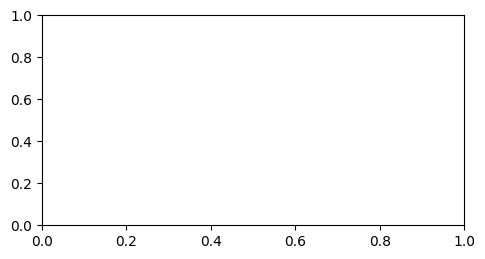

In [7]:
# Plot curves (loss/acc + F1/AUC)
epochs = range(1, max_epochs + 1)
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.subplot(2, 2, 2)
plt.plot(epochs, train_accs, label="Train acc")
plt.plot(epochs, val_accs, label="Val acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.subplot(2, 2, 3)
plt.plot(epochs, train_f1s, label="Train F1")
plt.plot(epochs, val_f1s, label="Val F1")
plt.xlabel("Epoch"); plt.ylabel("F1"); plt.legend()
plt.subplot(2, 2, 4)
plt.plot(epochs, train_aucs, label="Train ROC AUC")
plt.plot(epochs, val_aucs, label="Val ROC AUC")
plt.xlabel("Epoch"); plt.ylabel("AUC"); plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrix for the best checkpoint
if best_cm is not None:
    cm = confusion_matrix(*best_cm)
    disp = ConfusionMatrixDisplay(cm, display_labels=["NonFight", "Fight"])
    disp.plot(cmap="Blues"); plt.title("Best Val Confusion Matrix"); plt.show()